**Chapter 4: The Edge of Science and Global Trends**

**Lesson 12:**

# 🧩 Project 6: Intelligent Noise Removal with AI

Before diving into complex AI denoisers, we need to understand the physics of sound and how traditional Digital Signal Processing (DSP) tackles noise. In this session, we will explore both classic frequency filtering and cutting-edge streaming AI.

### 1️⃣ Installing and Importing Libraries


In [18]:
%pip install -v -i https://package-mirror.liara.ir/repository/pypi/simple noisereduce onnxruntime pyaudio librosa matplotlib numpy scipy ipywidgets soundfile requests --trusted-host package-mirror.liara.ir --quiet

import os
import time
import warnings
import requests
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import noisereduce as nr
import onnxruntime as ort
import pyaudio
from scipy.signal import butter, sosfilt
import warnings

from IPython.display import Audio, display, clear_output, HTML
from ipywidgets import interact, FloatSlider, IntSlider, Button, VBox, HBox, Output, HTML, Layout

warnings.filterwarnings('ignore')
plt.style.use('dark_background') 
plt.rcParams['figure.figsize'] = (14, 4)

print("✅ Laboratory Environment Initialized.")

Looking in indexes: https://package-mirror.liara.ir/repository/pypi/simple
Note: you may need to restart the kernel to use updated packages.
✅ Laboratory Environment Initialized.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2️⃣ Educational Dashboard 1: Understanding Frequency Filters



Every sound is a mixture of frequencies. A **Low-Pass Filter** allows low frequencies (like a bass or deep voice) to pass while cutting off high frequencies (like hissing or sharp noise).

> 💡 **Interactive Task:** Play with the cutoff slider below. Watch how cutting off higher frequencies changes the raw waveform and the frequency spectrum of the audio.

In [ ]:
def butter_lowpass(cutoff, sr, order=5):
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    return butter(order, normal_cutoff, btype='low', output='sos')

file_name = "voice.wav"                    
desired_sr = 22050                         

audio_original, sr_orig = librosa.load(file_name, sr=None, duration=7.0)   # فقط ۵ ثانیه اول
if sr_orig != desired_sr:
    audio_original = librosa.resample(audio_original, orig_sr=sr_orig, target_sr=desired_sr)
sr = desired_sr

# --- Add Gaussian noise to your voice ---
noise_level = 0.05                          
noise = noise_level * np.random.randn(len(audio_original))
noisy_signal = audio_original + noise

clean_signal = audio_original

print(f"✅ Voice file loaded: {len(audio_original)/sr:.1f}s, SR={sr}Hz")
print(f"🔊 Added noise with std={noise_level}")

@interact
def interactive_filter(
    cutoff=IntSlider(value=8000, min=500, max=11000, step=500, 
                     description='Cutoff (Hz):', layout=Layout(width='500px'))
):
    sos = butter_lowpass(cutoff, sr)
    filtered_signal = sosfilt(sos, noisy_signal)

    t = np.linspace(0, len(filtered_signal)/sr, len(filtered_signal), endpoint=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    zoom_samples = min(1000, len(t))
    ax1.plot(t[:zoom_samples], noisy_signal[:zoom_samples], alpha=0.5, 
             label='Voice + Noise', color='red')
    ax1.plot(t[:zoom_samples], filtered_signal[:zoom_samples], 
             label=f'Filtered (low‑pass < {cutoff}Hz)', color='cyan', linewidth=2)
    ax1.set_title("Time Domain: Waveform (Your Voice)")
    ax1.set_xlabel("Time (s)")
    ax1.legend()

    ax2.magnitude_spectrum(noisy_signal, Fs=sr, scale='dB', alpha=0.5, 
                           label='Noisy', color='red')
    ax2.magnitude_spectrum(filtered_signal, Fs=sr, scale='dB', 
                           label='Filtered', color='cyan')
    ax2.set_title("Frequency Domain: Magnitude Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_xlim(0, 11000)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    display(HTML("<b>🔊 Filtered Audio Output:</b>"))
    display(Audio(filtered_signal, rate=sr))

✅ Voice file loaded: 7.0s, SR=22050Hz
🔊 Added noise with std=0.05


interactive(children=(IntSlider(value=8000, description='Cutoff (Hz):', layout=Layout(width='500px'), max=1100…

### 3️⃣ Educational Dashboard 2: The Magic of Spectral Gating



Filters are great, but they cut out *everything* above a certain frequency. What if our core audio (like a human voice) and the noise exist in the *same* frequency range? 

Enter **Spectral Gating**. 
1. We calculate a "Noise Profile" (the average background noise).
2. We apply a mathematical gate: $S_{clean}(f, t) = S_{noisy}(f, t) \times M(f, t)$
3. If the audio energy at a specific frequency drops below our threshold, we squash it to zero!

> 💡 **Interactive Task:** Move the Threshold slider. See how aggressively increasing the threshold squashes the noise floor, leaving only the prominent peaks (our actual signal).

In [ ]:
# SPECTRAL GATING INTUITION DASHBOARD
@interact
def spectral_gate_simulator(
    threshold_db=FloatSlider(value=-20, min=-60, max=80, step=2, description='Threshold (dB):', layout=Layout(width='500px'))
):
    # Simulating a single FFT frame of frequencies
    freq_bins = np.linspace(0, 4000, 500)
    signal_peaks = 10 * np.exp(-((freq_bins - 1000)**2) / 5000) + 8 * np.exp(-((freq_bins - 2500)**2) / 4000)
    noise_floor = np.random.normal(2, 0.5, size=500)
    
    raw_spectrum_db = 20 * np.log10(signal_peaks + noise_floor)
    
    # Gating Logic
    gated_spectrum_db = np.copy(raw_spectrum_db)
    gated_spectrum_db[gated_spectrum_db < threshold_db] = -80 
    
    plt.figure(figsize=(14, 5))
    plt.plot(freq_bins, raw_spectrum_db, label='Raw Spectrum (Noisy)', color='red', alpha=0.6)
    plt.plot(freq_bins, gated_spectrum_db, label='After Gating', color='green', linewidth=2)
    plt.axhline(y=threshold_db, color='white', linestyle='--', label='Gate Threshold')
    
    plt.title("How Spectral Gating Masks Noise")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.ylim(-20, 50)
    plt.legend()
    plt.fill_between(freq_bins, -40, threshold_db, color='gray', alpha=0.2)
    plt.show()

interactive(children=(FloatSlider(value=-20.0, description='Threshold (dB):', layout=Layout(width='500px'), ma…

### 4️⃣ The Ultimate Real-World Test: The Guitar & Hairdryer Challenge

Now that we understand the math, let's put it to the test. 
We will load **DeepFilterNet**—an advanced AI model utilizing ONNX architecture that won the DNS (Deep Noise Suppression) Challenge. 

**The Setup:**
1. Grab your classical guitar (or prepare to speak).
2. Turn on a hairdryer or vacuum cleaner in the background.
3. Record a 7-second live clip.
4. Watch the AI strip the mechanical noise completely while preserving the harmonic richness of the instrument/voice.

In [ ]:
# AI SETUP & LIVE MICROPHONE CAPTURE
MODEL_FILE = "denoiser_model.onnx"
MODEL_URL = "https://github.com/yuyun2000/SpeechDenoiser/raw/refs/heads/main/48k/denoiser_model.onnx"

# Download Model if not exists
if not os.path.exists(MODEL_FILE):
    print("📥 Downloading ONNX AI Model (DeepFilterNet)...")
    r = requests.get(MODEL_URL)
    with open(MODEL_FILE, "wb") as f:
        f.write(r.content)
    print("✅ Model downloaded.")

# Initialize ONNX Session
session = ort.InferenceSession(MODEL_FILE)
print("🤖 AI Denoiser Engine Ready.")

# Live Recording Configuration
RATE = 48000  
CHUNK = 1024
FORMAT = pyaudio.paInt16
CHANNELS = 1

def record_live_audio(duration=7):
    p = pyaudio.PyAudio()
    print(f"\n🔴 RECORDING FOR {duration} SECONDS... Speak and make some noise!")
    stream = p.open(format=FORMAT, channels=CHANNELS, rate=RATE, input=True, frames_per_buffer=CHUNK)
    
    frames = []
    for _ in range(0, int(RATE / CHUNK * duration)):
        data = stream.read(CHUNK, exception_on_overflow=False)
        frames.append(data)
        
    stream.stop_stream()
    stream.close()
    p.terminate()
    print("✅ Recording Complete.")
    
    audio_data = np.frombuffer(b''.join(frames), dtype=np.int16).astype(np.float32) / 32768.0
    return audio_data

rec_out = Output()
btn_record = Button(description="🎙️ Start Live Recording (7s)", button_style="danger", layout=Layout(width='300px', height='50px'))

def on_record_clicked(b):
    with rec_out:
        clear_output()
        global live_audio
        live_audio = record_live_audio(duration=7)
        display(HTML("<br><b>Raw Noisy Recording:</b>"))
        display(Audio(live_audio, rate=RATE))

btn_record.on_click(on_record_clicked)
display(VBox([btn_record, rec_out]))

🤖 AI Denoiser Engine Ready.


### 5️⃣ Processing the Recording


Let's process the audio we just recorded using two different paradigms:
1. **Classic Spectral Gating (Offline DSP):** Computes the noise profile of the *entire* audio file and reduces stationary noises (like fan hums).
2. **DeepFilterNet AI (Streaming Mode):** Operates frame-by-frame, continuously updating its hidden memory (`states`) to suppress dynamic, non-stationary noises in real-time.

⚙️ Processing via Spectral Gating (Classic DSP, Offline)...
🤖 Processing via DeepFilterNet (AI, Streaming Mode)...
✅ AI Processing Complete.


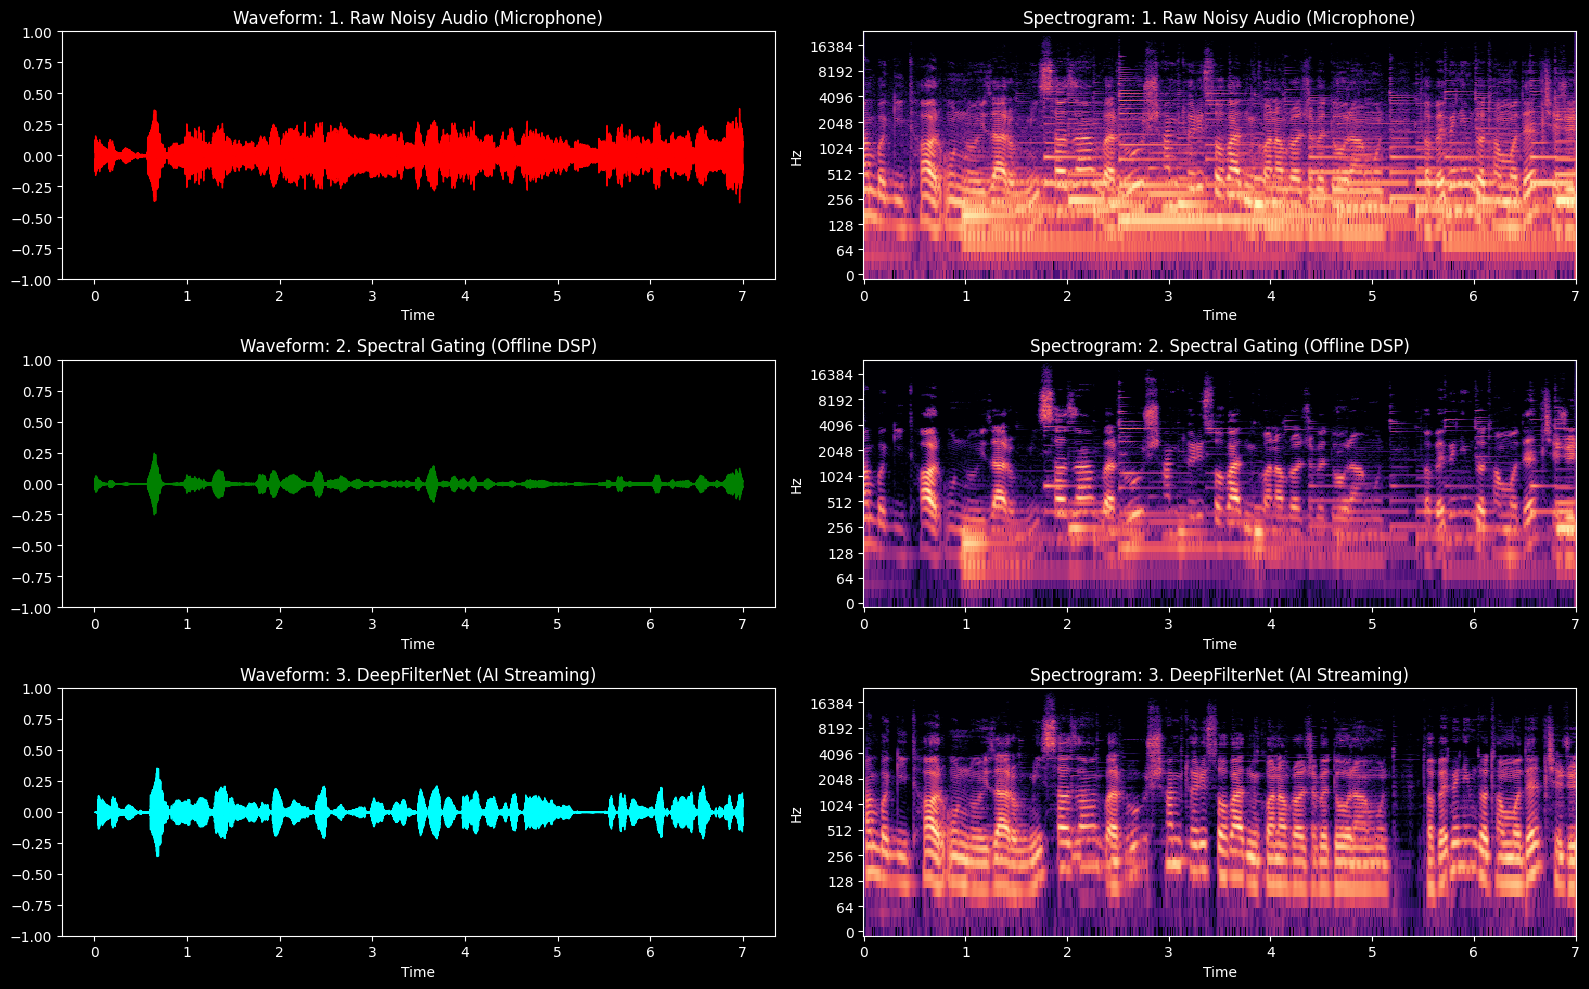

HTML(value='<hr><h3>🎧 Listen and Compare:</h3>')

HTML(value='<b>1. Original Noisy Audio (Live Recording):</b>')

HTML(value='<b>2. Spectral Gating Output (Noisereduce):</b>')

HTML(value='<b>3. DeepFilterNet Output (AI):</b>')

In [32]:
# DENOISING & VISUAL COMPARISON
if 'live_audio' not in globals():
    raise ValueError("⚠️ Please run the recording cell above and record some audio first!")

print("⚙️ Processing via Spectral Gating (Classic DSP, Offline)...")
audio_sg = nr.reduce_noise(y=live_audio, sr=RATE, stationary=False, prop_decrease=0.95)

print("🤖 Processing via DeepFilterNet (AI, Streaming Mode)...")

# Dynamic Initialization of ONNX Inputs 
inputs_meta = session.get_inputs()
frame_shape = []
frame_size = 0

for meta in inputs_meta:
    shape = [1 if isinstance(dim, str) else dim for dim in meta.shape]
    
    if meta.name == 'input_frame':
        frame_shape = shape
        frame_size = shape[-1]
    elif meta.name == 'states':
        states = np.zeros(shape, dtype=np.float32) 
    elif meta.name == 'atten_lim_db':
        atten_lim_db = np.array(100.0, dtype=np.float32)
        if len(shape) > 0:
            atten_lim_db = atten_lim_db.reshape(shape)

# Padding the Audio 
pad_len = frame_size - (len(live_audio) % frame_size)
if pad_len != frame_size:
    audio_padded = np.pad(live_audio, (0, pad_len))
else:
    audio_padded = live_audio

# The Streaming Loop (Frame by Frame Processing) 
out_frames = []
for i in range(0, len(audio_padded), frame_size):
    chunk = audio_padded[i : i + frame_size]
    input_frame = chunk.reshape(frame_shape).astype(np.float32)
    
    feed_dict = {
        'input_frame': input_frame,
        'states': states,
        'atten_lim_db': atten_lim_db
    }
    
    out = session.run(None, feed_dict)
    
    out_chunk = out[0]
    states = out[1] # The model's memory passes to the next frame
    
    out_frames.append(out_chunk.flatten())

# Concatenate all clean chunks and trim the padding
audio_ai = np.concatenate(out_frames)[:len(live_audio)]
print("✅ AI Processing Complete.")

fig, axes = plt.subplots(3, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [1, 1]})

signals = [
    (live_audio, '1. Raw Noisy Audio (Microphone)', 'red'),
    (audio_sg, '2. Spectral Gating (Offline DSP)', 'green'),
    (audio_ai, '3. DeepFilterNet (AI Streaming)', 'cyan')
]

for i, (sig, title, color) in enumerate(signals):
    librosa.display.waveshow(sig, sr=RATE, ax=axes[i, 0], color=color)
    axes[i, 0].set_title(f"Waveform: {title}")
    axes[i, 0].set_ylim(-1, 1)
    
    D = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    img = librosa.display.specshow(D, sr=RATE, x_axis='time', y_axis='log', ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f"Spectrogram: {title}")

plt.tight_layout()
plt.show()

display(HTML("<hr><h3>🎧 Listen and Compare:</h3>"))
display(HTML("<b>1. Original Noisy Audio (Live Recording):</b>"))
display(Audio(live_audio, rate=RATE))

display(HTML("<b>2. Spectral Gating Output (Noisereduce):</b>"))
display(Audio(audio_sg, rate=RATE))

display(HTML("<b>3. DeepFilterNet Output (AI):</b>"))
display(Audio(audio_ai, rate=RATE))

### 🏁 Conclusion


**What you accomplished in this project:**

1. **DSP Fundamentals** – Visualized how classic low-pass and high-pass filters manipulate the frequency domain to cut out extreme ends of the audio spectrum.
2. **Spectral Gating Extraction** – Understood how algorithms calculate a noise floor and selectively "squash" frequencies falling below a mathematical threshold.
3. **Live Streaming AI Denoising** – Deployed an ONNX-based Deep Learning model (DeepFilterNet) designed to handle dynamic, complex background noises.
4. **Real-World Audio Engineering** – Handled buffer chunking and passed neural network memory (`states`) frame-by-frame to simulate zero-latency edge inference.

You have now constructed a professional-grade noise suppression pipeline capable of operating entirely locally on a CPU, similar to the technology inside modern noise-canceling headphones and communication platforms.

**In the next video:**

**Project 7 – Deep Learning Voice Cloning** Move beyond analyzing voice to generating it. We will implement Zero-Shot TTS to clone your exact voice and tone using just a 3-second audio sample.